In [1]:
import pandas as pd
import numpy as np
import re

In [ ]:
#complete comment data from 2019 - 2024, from r/wallstreetbets; 
# df_comments = pd.read_csv(r"G:\Interview Projects\reddit\reddit_wsb.csv") #kaggle test_data
df_comments = pd.read_cav(r"")

df_comments

,title,score,id,url,comms_num,created,body,timestamp
0,"It's not about the money, it's about sending a...",55,l6ulcx,https://v.redd.it/6j75regs72e61,6,1.611863e+09,NaN,2021-01-28 21:37:41
1,Math Professor Scott Steiner says the numbers ...,110,l6uibd,https://v.redd.it/ah50lyny62e61,23,1.611862e+09,NaN,2021-01-28 21:32:10
2,Exit the system,0,l6uhhn,https://www.reddit.com/r/wallstreetbets/commen...,47,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to g...,2021-01-28 21:30:35
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,l6ugk6,https://sec.report/Document/0001193125-21-019848/,74,1.611862e+09,NaN,2021-01-28 21:28:57
4,"Not to distract from GME, just thought our AMC...",71,l6ufgy,https://i.redd.it/4h2sukb662e61.jpg,156,1.611862e+09,NaN,2021-01-28 21:26:56
...,...,...,...,...,...,...,...,...
53182,What I Learned Investigating SAVA FUD Spreaders,238,owd2pn,https://www.reddit.com/r/wallstreetbets/commen...,87,1.627906e+09,***TLDR: Three bitter scientists partnered up ...,2021-08-02 15:03:27
53183,"Daily Popular Tickers Thread for August 02, 20...",228,owd1a5,https://www.reddit.com/r/wallstreetbets/commen...,1070,1.627906e+09,\nYour daily hype thread. Please keep the shit...,2021-08-02 15:01:03
53184,Hitler reacts to the market being irrational,7398,owc5dr,https://v.redd.it/46jxu074exe71,372,1.627902e+09,NaN,2021-08-02 13:59:35
53185,"Daily Discussion Thread for August 02, 2021",338,owbfjf,https://www.reddit.com/r/wallstreetbets/commen...,11688,1.627898e+09,Your daily trading discussion thread. Please k...,2021-08-02 13:00:16


In [18]:
#list of stocks in S&P 
l = pd.read_csv(r"G:\InterviewProjects\reddit\S&P 500 Historical Components & Changes(07-12-2025).csv")
l = l[(pd.to_datetime(l["date"]) >= "2019-01-01") & (pd.to_datetime(l["date"]) <= "2024-12-31") ]
l = l.iloc[-1:,:]

my_tickers = list(l.iloc[0,1].split(','))

#load security names from sec
import requests
import json
import re

url = "https://www.sec.gov/files/company_tickers.json"
resp = requests.get(url, headers={"User-Agent": "YuxinLi (yl14490@nyu.edu)"})
data = resp.json()

df_map = pd.DataFrame.from_dict(data, orient="index")

df_map["cik_str"] = df_map["cik_str"].astype(str).str.zfill(10)

matched = df_map[df_map['ticker'].isin(my_tickers)]

words_to_remove = ['inc', '.', 'corp']
pattern = r'\b(' + '|'.join(words_to_remove) + r')\b'

matched['name'] = matched['title'].str.replace(pattern, '', flags=re.IGNORECASE, regex=True)
matched.to_csv("matched_stocks.csv",index = False)
matched


C:\Users\Anya Yuxin Li\AppData\Local\Temp\ipykernel_35264\2333947965.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched['name'] = matched['title'].str.replace(pattern, '', flags=re.IGNORECASE, regex=True)


,cik_str,ticker,title,name
0,0001045810,NVDA,NVIDIA CORP,NVIDIA
1,0000789019,MSFT,MICROSOFT CORP,MICROSOFT
2,0000320193,AAPL,Apple Inc.,Apple.
3,0001652044,GOOGL,Alphabet Inc.,Alphabet.
4,0001018724,AMZN,AMAZON COM INC,AMAZONCOM
...,...,...,...,...
1525,0000037785,FMC,FMC CORP,FMC
7394,0001652044,GOOG,Alphabet Inc.,Alphabet.
7514,0000035527,FITB,FIFTH THIRD BANCORP,FIFTHTHIRDBANCORP
7523,0001754301,FOX,Fox Corp,Fox


In [ ]:
import requests
import time
import pandas as pd

stocks = list(matched['ticker'])
api_key = ""
results = []

for ticker in stocks:
    url = f"https://www.alphavantage.co/query?function=EARNINGS&symbol={ticker}&apikey={api_key}"
    r = requests.get(url)
    data = r.json()

    # results.append(data)

    if "quarterlyEarnings" in data:
        for q in data["quarterlyEarnings"]:
            fiscal_end = q.get("fiscalDateEnding")
            reported = q.get("reportedDate")
            actual_eps = q.get("reportedEPS")
            est_eps = q.get("estimatedEPS")
            surprise = q.get("surprise")
            surprise_pct = q.get("surprisePercentage")

            results.append({
                "ticker": ticker,
                "fiscalDateEnding": fiscal_end,
                "reportedDate": reported,
                "reportedEPS": actual_eps,
                "estimatedEPS": est_eps,
                "surprise": surprise,
                "surprisePercentage": surprise_pct
            })


        #     if fiscal_end == "2021-06-30":
        #         results.append({
        #             "ticker": ticker,
        #             "fiscalDateEnding": fiscal_end,
        #             "reportedDate": reported,
        #             "reportedEPS": actual_eps,
        #             "estimatedEPS": est_eps,
        #             "surprise": surprise,
        #             "surprisePercentage": surprise_pct
        #         })
    print(f"Done: {ticker}")
    time.sleep(1) 

    df_results = pd.DataFrame(results) #this has all the earnings until Q2 2025 
    

Done: NVDA
Done: MSFT
Done: AAPL
Done: GOOGL
Done: AMZN
Done: AVGO
Done: TSLA
Done: JPM
Done: WMT
Done: ORCL
Done: V
Done: LLY
Done: NFLX
Done: MA
Done: XOM
Done: COST
Done: JNJ
Done: HD
Done: PG
Done: BAC
Done: ABBV
Done: CVX
Done: GE
Done: KO
Done: TMUS
Done: UNH
Done: CSCO
Done: WFC
Done: PM
Done: AMD
Done: MS
Done: IBM
Done: CRM
Done: GS
Done: ABT
Done: AXP
Done: MCD
Done: LIN
Done: MRK
Done: DIS
Done: T
Done: RTX
Done: PEP
Done: CAT
Done: NOW
Done: INTU
Done: TMO
Done: VZ
Done: TXN
Done: BKNG
Done: C
Done: ANET
Done: BA
Done: BLK
Done: QCOM
Done: SCHW
Done: ISRG
Done: SPGI
Done: BSX
Done: ACN
Done: TJX
Done: MU
Done: LOW
Done: AMGN
Done: ADBE
Done: SYK
Done: NEE
Done: GILD
Done: PGR
Done: APH
Done: COF
Done: PFE
Done: DHR
Done: HON
Done: ETN
Done: LRCX
Done: UNP
Done: AMAT
Done: DE
Done: CMCSA
Done: ADI
Done: KLAC
Done: MDT
Done: ADP
Done: COP
Done: INTC
Done: WELL
Done: MO
Done: CB
Done: SNPS
Done: NKE
Done: LMT
Done: PLD
Done: VRTX
Done: SO
Done: ICE
Done: MMC
Done: CDNS
Done: H

preview of the EPS surprise data
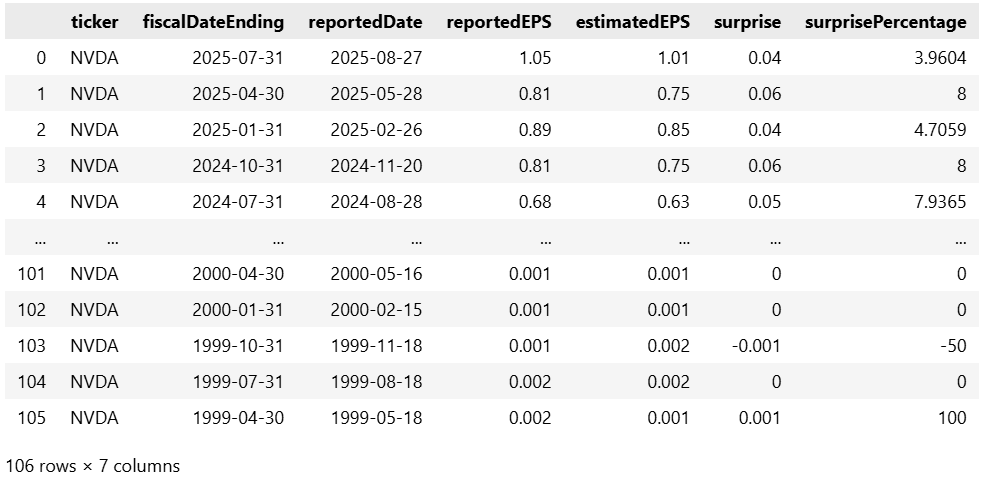

In [20]:
# df_results.to_csv("earningreleasedatesandsurprises.csv",index=False)
import pandas as pd
df_results = pd.read_csv(r"G:\InterviewProjects\reddit\earningreleasedatesandsurprises.csv")

df_results['fiscalDateEnding'] = pd.to_datetime(df_results['fiscalDateEnding'])
df_results['reportedDate'] = pd.to_datetime(df_results['reportedDate'])
df_results

,ticker,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage
0,NVDA,2025-07-31,2025-08-27,1.05,1.0000,0.0500,5.0000
1,NVDA,2025-04-30,2025-05-28,0.96,0.9300,0.0300,3.2258
2,NVDA,2025-01-31,2025-02-26,0.89,0.8459,0.0441,5.2134
3,NVDA,2024-10-31,2024-11-20,0.81,0.7400,0.0700,9.4595
4,NVDA,2024-07-31,2024-08-28,0.68,0.6300,0.0500,7.9365
...,...,...,...,...,...,...,...
48330,UA,2017-03-31,2017-04-27,-0.01,-0.0400,0.0300,75.0000
48331,UA,2016-12-31,2017-01-31,0.23,0.2400,-0.0100,-4.1667
48332,UA,2016-09-30,2016-10-25,0.29,0.2400,0.0500,20.8333
48333,UA,2016-06-30,2016-07-26,0.01,0.0200,-0.0100,-50.0000


In [21]:
df_results = df_results[(df_results['reportedDate'].dt.year>=2019) & (df_results['reportedDate'].dt.year <= 2024)]
df_results

,ticker,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage
3,NVDA,2024-10-31,2024-11-20,0.810,0.740,0.070,9.4595
4,NVDA,2024-07-31,2024-08-28,0.680,0.630,0.050,7.9365
5,NVDA,2024-04-30,2024-05-22,0.612,0.559,0.053,9.4812
6,NVDA,2024-01-31,2024-02-21,0.516,0.461,0.055,11.9306
7,NVDA,2023-10-31,2023-11-21,0.402,0.336,0.066,19.6429
...,...,...,...,...,...,...,...
48319,UA,2019-12-31,2020-02-11,0.100,0.110,-0.010,-9.0909
48320,UA,2019-09-30,2019-11-04,0.230,0.190,0.040,21.0526
48321,UA,2019-06-30,2019-07-30,-0.040,-0.040,0.000,0.0000
48322,UA,2019-03-31,2019-05-02,0.050,-0.010,0.060,600.0000


In [ ]:
from dateutil.relativedelta import relativedelta

earnings_df = df_results.copy()
# type(earnings_df['reportedDate'][0])
earnings_df = earnings_df[(pd.to_datetime(earnings_df['reportedDate']) >= "2019-01-01") & (pd.to_datetime(earnings_df['reportedDate']) <= "2024-12-31") ]
earnings_df['year'] = pd.to_datetime(earnings_df['fiscalDateEnding']).dt.year
# earnings_df['month'] = pd.to_datetime(earnings_df['fiscalDateEnding']).dt.month

earnings_df = earnings_df.groupby(by = ["ticker","year"],as_index=False).apply(
    lambda x: x.sort_values('fiscalDateEnding').assign(quarter = range(1,len(x)+1))
).reset_index(drop=True)

earnings_df['reportedDate'] = pd.to_datetime(earnings_df['reportedDate'])
earnings_df['window_start'] = earnings_df['reportedDate'].apply(lambda x: x - relativedelta(months=1))
earnings_df['window_end'] = earnings_df['reportedDate'].apply(lambda x: x - relativedelta(days=1))

earnings_df

,ticker,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,year,quarter,window_start,window_end
0,A,2019-01-31,2019-02-20,0.76,0.73,0.03,4.1096,2019,1,2019-01-20,2019-02-19
1,A,2019-04-30,2019-05-14,0.71,0.72,-0.01,-1.3889,2019,2,2019-04-14,2019-05-13
2,A,2019-07-31,2019-08-14,0.76,0.72,0.04,5.5556,2019,3,2019-07-14,2019-08-13
3,A,2019-10-31,2019-11-25,0.89,0.85,0.04,4.7059,2019,4,2019-10-25,2019-11-24
4,A,2020-01-31,2020-02-18,0.81,0.81,0.00,0.0000,2020,1,2020-01-18,2020-02-17
...,...,...,...,...,...,...,...,...,...,...,...
11041,ZTS,2023-09-30,2023-11-02,1.36,1.36,0.00,0.0000,2023,3,2023-10-02,2023-11-01
11042,ZTS,2023-12-31,2024-02-13,1.24,1.32,-0.08,-6.0606,2023,4,2024-01-13,2024-02-12
11043,ZTS,2024-03-31,2024-05-02,1.38,1.34,0.04,2.9851,2024,1,2024-04-02,2024-05-01
11044,ZTS,2024-06-30,2024-08-06,1.56,1.49,0.07,4.6980,2024,2,2024-07-06,2024-08-05


In [24]:
earnings_df.to_csv("temp_quarterindex.csv",index = False)
earnings_df

,ticker,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,year,quarter,window_start,window_end
0,A,2019-01-31,2019-02-20,0.76,0.73,0.03,4.1096,2019,1,2019-01-20,2019-02-19
1,A,2019-04-30,2019-05-14,0.71,0.72,-0.01,-1.3889,2019,2,2019-04-14,2019-05-13
2,A,2019-07-31,2019-08-14,0.76,0.72,0.04,5.5556,2019,3,2019-07-14,2019-08-13
3,A,2019-10-31,2019-11-25,0.89,0.85,0.04,4.7059,2019,4,2019-10-25,2019-11-24
4,A,2020-01-31,2020-02-18,0.81,0.81,0.00,0.0000,2020,1,2020-01-18,2020-02-17
...,...,...,...,...,...,...,...,...,...,...,...
11041,ZTS,2023-09-30,2023-11-02,1.36,1.36,0.00,0.0000,2023,3,2023-10-02,2023-11-01
11042,ZTS,2023-12-31,2024-02-13,1.24,1.32,-0.08,-6.0606,2023,4,2024-01-13,2024-02-12
11043,ZTS,2024-03-31,2024-05-02,1.38,1.34,0.04,2.9851,2024,1,2024-04-02,2024-05-01
11044,ZTS,2024-06-30,2024-08-06,1.56,1.49,0.07,4.6980,2024,2,2024-07-06,2024-08-05


In [25]:
earnings_df = pd.read_csv(r"temp_quarterindex.csv")
earnings_df

,ticker,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,year,quarter,window_start,window_end
0,A,2019-01-31,2019-02-20,0.76,0.73,0.03,4.1096,2019,1,2019-01-20,2019-02-19
1,A,2019-04-30,2019-05-14,0.71,0.72,-0.01,-1.3889,2019,2,2019-04-14,2019-05-13
2,A,2019-07-31,2019-08-14,0.76,0.72,0.04,5.5556,2019,3,2019-07-14,2019-08-13
3,A,2019-10-31,2019-11-25,0.89,0.85,0.04,4.7059,2019,4,2019-10-25,2019-11-24
4,A,2020-01-31,2020-02-18,0.81,0.81,0.00,0.0000,2020,1,2020-01-18,2020-02-17
...,...,...,...,...,...,...,...,...,...,...,...
11041,ZTS,2023-09-30,2023-11-02,1.36,1.36,0.00,0.0000,2023,3,2023-10-02,2023-11-01
11042,ZTS,2023-12-31,2024-02-13,1.24,1.32,-0.08,-6.0606,2023,4,2024-01-13,2024-02-12
11043,ZTS,2024-03-31,2024-05-02,1.38,1.34,0.04,2.9851,2024,1,2024-04-02,2024-05-01
11044,ZTS,2024-06-30,2024-08-06,1.56,1.49,0.07,4.6980,2024,2,2024-07-06,2024-08-05


In [ ]:
#importing filtered dat
df_comments = pd.read_csv(r"")
df_comments.columns

Index(['id', 'author', 'created_utc', 'score', 'subreddit', 'title',
       'selftext', 'num_comments', 'url', 'upvote_ratio'],
      dtype='object')

In [12]:
#extract the relevant stocks of each comment
# submission & comment data
# df_comments = pd.read_csv(r"F:\reddit data\reddit\submissions\filtered data\filteredsubandcoms.csv")
df_comments


,id,author,created_utc,score,subreddit,title,selftext,num_comments,url,upvote_ratio
0,npgy6l,TheMarkIII,1622505919,1,wallstreetbets,Caught a glimpse of AMC on its way to the moon!!,NaN,1.0,https://i.redd.it/tuw6d5qlpj271.jpg,1.00
1,nph22g,macfern,1622506236,1,wallstreetbets,Wanda Group Fully Withdraws From AMC in Nearly...,NaN,1.0,https://www.google.com/amp/s/www.theepochtimes...,1.00
2,nph34u,randyzmzzzz,1622506330,1,wallstreetbets,"AMC at 42nd street, NYC",NaN,1.0,https://i.redd.it/9i2q5u6tqj271.jpg,1.00
3,nph718,TheHighness1,1622506662,1,wallstreetbets,Ape Strong together,NaN,1.0,https://i.redd.it/fzn8646trj271.jpg,1.00
4,nph8m3,wowwkwkssiw,1622506792,1,wallstreetbets,Elon Musk Charged With Second Degree Murder,NaN,1.0,https://theproffessionalbroker.blogspot.com/20...,1.00
...,...,...,...,...,...,...,...,...,...,...
50346,pfhn3d,_disguy,1630452959,2117,wallstreetbets,GME has consistently spiked every T-17 days be...,NaN,252.0,https://i.redd.it/zhjf7do34sk71.png,0.93
50347,pfhpj2,Kobeblackmambattv,1630453193,75,wallstreetbets,$GENI DD | I'm either a $GENIus or a retard. 2...,&amp;#x200B;\n\nhttps://preview.redd.it/bfclvu...,45.0,https://www.reddit.com/r/wallstreetbets/commen...,0.89
50348,pfhq3j,poohyawn,1630453246,2,wallstreetbets,Does anyone know what the first stock symbol i...,NaN,14.0,https://i.redd.it/4jomom135sk71.jpg,0.61
50349,pfhtyf,outphase84,1630453627,2,wallstreetbets,1.4K to 7.1K overnight on FIVN puts. Thanks ZM!,NaN,2.0,https://i.redd.it/3drt4ft76sk71.jpg,1.00


In [13]:
from fuzzywuzzy import fuzz, process
def create_stock_patterns(df_stocks):
    stock_patterns = {}
    
    for _, row in df_stocks.iterrows():
        ticker = row['ticker']
        name = row['name']
        title = row['title']
        
        patterns = set()
        
        # Add ticker symbol
        patterns.add(ticker.upper())
        
        # Add company names
        patterns.add(name.lower())
        patterns.add(title.lower())
        
        # Remove common corporate suffixes and create variations
        clean_name = re.sub(r'\b(inc\.?|corp\.?|corporation|company|co\.?|ltd\.?)\b', '', name.lower()).strip()
        clean_title = re.sub(r'\b(inc\.?|corp\.?|corporation|company|co\.?|ltd\.?)\b', '', title.lower()).strip()
        
        patterns.add(clean_name)
        patterns.add(clean_title)
        
        # Add common abbreviations/nicknames (you'll need to build this)
        nickname_map = {
            'AAPL': ['apple'],
            'MSFT': ['microsoft', 'msft'],
            'GOOGL': ['google', 'alphabet'],
            'AMZN': ['amazon'],
            'NVDA': ['nvidia'],
            # Add more as needed
        }
        
        if ticker in nickname_map:
            patterns.update(nickname_map[ticker])
        
        stock_patterns[ticker] = list(patterns)
    
    return stock_patterns

def fast_stock_mentions(text, stock_patterns):
    """
    Much faster approach - exact matching only
    """
    text_upper = text.upper()
    text_lower = text.lower()
    mentions = []
    
    for ticker, patterns in stock_patterns.items():
        # Quick ticker check first
        if re.search(r'\b' + re.escape(ticker) + r'\b', text_upper):
            mentions.append({
                'ticker': ticker,
                'match_type': 'exact_ticker',
                'confidence': 100
            })
            continue
        
        # Quick substring check for names
        for pattern in patterns:
            if pattern.lower() in text_lower:
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'exact_name', 
                    'confidence': 95
                })
                break
    
    return mentions

In [14]:
def find_stock_mentions(text, stock_patterns, min_similarity=80):
    """
    Find stock mentions using multiple matching strategies
    """
    text_lower = text.lower()
    mentions = []
    
    for ticker, patterns in stock_patterns.items():
        # Level 1: Exact ticker match (case-insensitive)
        if re.search(r'\b' + re.escape(ticker) + r'\b', text, re.IGNORECASE):
            mentions.append({
                'ticker': ticker,
                'match_type': 'exact_ticker',
                'confidence': 100
            })
            continue
        
        # Level 2: Exact name match
        for pattern in patterns:
            if pattern in text_lower:
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'exact_name',
                    'confidence': 95
                })
                break
        
        # Level 3: Fuzzy matching
        words = text_lower.split()
        for pattern in patterns:
            for word in words:
                similarity = fuzz.ratio(pattern, word)
                if similarity >= min_similarity:
                    mentions.append({
                        'ticker': ticker,
                        'match_type': 'fuzzy',
                        'confidence': similarity
                    })
                    break
    
    return mentions

def smart_stock_mentions(text, stock_patterns):
    """
    Match stocks with smart ticker handling
    """
    mentions = []
    text_upper = text.upper()
    text_lower = text.lower()
    
    for ticker, patterns in stock_patterns.items():
        found = False
        
        # 1. Safe ticker matching (3+ chars or non-common words)
        for safe_ticker in patterns['safe_tickers']:
            if re.search(r'\b' + re.escape(safe_ticker) + r'\b', text_upper):
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'safe_ticker',
                    'confidence': 100
                })
                found = True
                break
        
        if found:
            continue
            
        # 2. Context-required tickers (like $A, or "buy A stock")
        for risky_ticker in patterns['require_context']:
            # Look for $ prefix
            if re.search(r'\$' + re.escape(risky_ticker) + r'\b', text_upper):
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'ticker_with_context',
                    'confidence': 95
                })
                found = True
                break
            
            # Look for stock context words nearby
            stock_context_pattern = rf'\b(?:stock|ticker|symbol|share|buy|sell|hold)\s+{re.escape(risky_ticker)}\b|\b{re.escape(risky_ticker)}\s+(?:stock|ticker|symbol|share|up|down|calls|puts)\b'
            if re.search(stock_context_pattern, text_upper):
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'ticker_with_context',
                    'confidence': 90
                })
                found = True
                break
        
        if found:
            continue
            
        # 3. Company name matching
        for company_name in patterns['company_names']:
            if len(company_name) > 3 and company_name.lower() in text_lower:
                mentions.append({
                    'ticker': ticker,
                    'match_type': 'company_name',
                    'confidence': 85
                })
                break
    
    return mentions

In [15]:
def create_enhanced_patterns(df_stocks):
    """
    Create more sophisticated patterns including common slang/nicknames
    """
    
    # Common stock market slang/nicknames
    slang_map = {
        'TSLA': ['tesla', 'elon', 'musk'],
        'GME': ['gamestop', 'gme', 'game stop'],
        'AMC': ['amc', 'movie theater'],
        'AAPL': ['apple', 'iphone', 'tim cook'],
        'MSFT': ['microsoft', 'bill gates'],
        'AMZN': ['amazon', 'bezos', 'aws'],
        'META': ['facebook', 'meta', 'zuckerberg', 'fb'],
        'GOOGL': ['google', 'alphabet', 'search'],
        'NVDA': ['nvidia', 'gpu', 'graphics'],
        # Add more based on your specific data
    }
    
    stock_patterns = {}
    for _, row in df_stocks.iterrows():
        ticker = row['ticker']
        patterns = []
        
        # Basic patterns
        patterns.extend([ticker, row['name'].lower(), row['title'].lower()])
        
        # Add slang if available
        if ticker in slang_map:
            patterns.extend(slang_map[ticker])
        
        # Clean patterns (remove duplicates, empty strings)
        patterns = list(set([p.strip() for p in patterns if p.strip()]))
        stock_patterns[ticker] = patterns
    
    return stock_patterns

def analyze_stock_mentions_fast(df_social, stock_patterns, batch_size=1000):
    """
    Process in batches with progress tracking and include all essential fields
    """
    results = []
    total_rows = len(df_social)
    
    # Define essential fields
    essential_fields = [
        'id', 'title', 'selftext', 'author', 'created_utc', 'score', 
        'num_comments', 'url', 'subreddit', 'upvote_ratio'
    ]
    
    for i in range(0, total_rows, batch_size):
        batch = df_social.iloc[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(total_rows-1)//batch_size + 1}")
        
        for idx, row in batch.iterrows():
            text = str(row.get('selftext', '')) + ' ' + str(row.get('title', ''))
            mentions = fast_stock_mentions(text, stock_patterns)  # Use fast version
            
            # Create base record with all essential fields
            base_record = {}
            for field in essential_fields:
                base_record[field] = row.get(field, None)
            
            for mention in mentions:
                # Create a complete record for each mention
                record = base_record.copy()  # Copy all the essential fields
                
                # Add stock mention specific fields
                record.update({
                    'ticker': mention['ticker'],
                    'match_type': mention['match_type'],
                    'confidence': mention['confidence']
                })
                
                results.append(record)
    
    return pd.DataFrame(results)
    return pd.DataFrame(results)

In [16]:
def create_smart_stock_patterns(df_stocks):
    """
    Create patterns with smart ticker filtering
    """
    # Define problematic tickers that shouldn't be matched
    SKIP_TICKERS = {
        'A',     # Too common as article
        'I',     # Too common as pronoun  
        'AM',    # Common word "am"
        'AN',    # Common word "an"
        'AS',    # Common word "as"
        'AT',    # Common word "at"
        'BE',    # Common word "be" 
        'BY',    # Common word "by"
        'DO',    # Common word "do"
        'GO',    # Common word "go"
        'HE',    # Common word "he"
        'IF',    # Common word "if"
        'IN',    # Common word "in"
        'IS',    # Common word "is"
        'IT',    # Common word "it"
        'MY',    # Common word "my"
        'NO',    # Common word "no"
        'OF',    # Common word "of"
        'ON',    # Common word "on"
        'OR',    # Common word "or"
        'SO',    # Common word "so"
        'TO',    # Common word "to"
        'UP',    # Common word "up"
        'US',    # Common word "us"
        'WE',    # Common word "we"
        # Add more as needed
    }
    
    # Minimum length for ticker matching
    MIN_TICKER_LENGTH = 2
    
    stock_patterns = {}
    
    for _, row in df_stocks.iterrows():
        ticker = row['ticker'].upper()
        name = row['name']
        title = row['title']
        
        patterns = {
            'safe_tickers': [],      # Tickers safe to match
            'company_names': [],     # Company name variations
            'require_context': []    # Tickers that need context (like "$A")
        }
        
        # Handle ticker matching
        if ticker in SKIP_TICKERS:
            # For problematic tickers, only match with $ prefix or clear stock context
            patterns['require_context'].append(ticker)
        elif len(ticker) >= MIN_TICKER_LENGTH:
            patterns['safe_tickers'].append(ticker)
        
        # Add company names (cleaned)
        clean_name = re.sub(r'\b(inc\.?|corp\.?|corporation|company|co\.?|ltd\.?)\b', '', name, flags=re.IGNORECASE).strip()
        clean_title = re.sub(r'\b(inc\.?|corp\.?|corporation|company|co\.?|ltd\.?)\b', '', title, flags=re.IGNORECASE).strip()
        
        patterns['company_names'].extend([name, title, clean_name, clean_title])
        
        # Remove empty/short names
        patterns['company_names'] = [n for n in patterns['company_names'] if len(n.strip()) > 2]
        
        stock_patterns[ticker] = patterns
    
    return stock_patterns

In [36]:
matched = pd.read_csv(r"G:\Interview Projects\reddit\data processing\matched_stocks.csv")
matched

,cik_str,ticker,title,name
0,1045810,NVDA,NVIDIA CORP,NVIDIA
1,789019,MSFT,MICROSOFT CORP,MICROSOFT
2,320193,AAPL,Apple Inc.,Apple.
3,1652044,GOOGL,Alphabet Inc.,Alphabet.
4,1018724,AMZN,AMAZON COM INC,AMAZONCOM
...,...,...,...,...
456,1652044,GOOG,Alphabet Inc.,Alphabet.
457,35527,FITB,FIFTH THIRD BANCORP,FIFTHTHIRDBANCORP
458,1754301,FOX,Fox Corp,Fox
459,1564708,NWS,NEWS CORP,NEWS


In [41]:
earnings_df.columns

Index(['ticker', 'fiscalDateEnding', 'reportedDate', 'reportedEPS',
       'estimatedEPS', 'surprise', 'surprisePercentage', 'year', 'quarter'],
      dtype='object')

In [44]:
#matching eps data with stocks' names
results = pd.merge(matched, earnings_df[(earnings_df['year']==2021) & (earnings_df['quarter']==2)], on = "ticker", how = "left")
results

# results.columns

,cik_str,ticker,title,name,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,year,quarter
0,1045810,NVDA,NVIDIA CORP,NVIDIA,2021-04-30,2021-05-26,0.0915,0.0822,0.0093,11.3139,2021.0,2.0
1,789019,MSFT,MICROSOFT CORP,MICROSOFT,2021-06-30,2021-07-27,2.1700,1.9200,0.2500,13.0208,2021.0,2.0
2,320193,AAPL,Apple Inc.,Apple.,2021-06-30,2021-07-27,1.3000,1.0100,0.2900,28.7129,2021.0,2.0
3,1652044,GOOGL,Alphabet Inc.,Alphabet.,2021-06-30,2021-07-27,1.3600,0.9600,0.4000,41.6667,2021.0,2.0
4,1018724,AMZN,AMAZON COM INC,AMAZONCOM,2021-06-30,2021-07-29,0.7600,0.6200,0.1400,22.5806,2021.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
456,1652044,GOOG,Alphabet Inc.,Alphabet.,2021-06-30,2021-07-27,1.3600,0.9600,0.4000,41.6667,2021.0,2.0
457,35527,FITB,FIFTH THIRD BANCORP,FIFTHTHIRDBANCORP,2021-06-30,2021-07-22,0.9400,0.8100,0.1300,16.0494,2021.0,2.0
458,1754301,FOX,Fox Corp,Fox,2021-06-30,2021-08-04,0.6500,0.6500,0.0000,0.0000,2021.0,2.0
459,1564708,NWS,NEWS CORP,NEWS,2021-06-30,2021-08-05,0.1600,0.0600,0.1000,166.6667,2021.0,2.0


In [47]:
# Use only exact matching
results['ticker'] = results['ticker'].astype(str)
results['title'] = results['title'].astype(str)
results['name'] = results['name'].astype(str)
# stock_patterns = create_enhanced_patterns(results)  # Your existing function
stock_patterns = create_smart_stock_patterns(results) #this avoids fuzzy match of tickers on certain frequently used words

# Test on just 100 rows first
# sample_df = df_comments.head(100)
# mentions_df = analyze_stock_mentions_fast(sample_df, stock_patterns)

mentions_df = analyze_stock_mentions_fast(df_comments, stock_patterns)
print(f"Found {len(mentions_df)} mentions")

Processing batch 1/51
Processing batch 2/51
Processing batch 3/51
Processing batch 4/51
Processing batch 5/51
Processing batch 6/51
Processing batch 7/51
Processing batch 8/51
Processing batch 9/51
Processing batch 10/51
Processing batch 11/51
Processing batch 12/51
Processing batch 13/51
Processing batch 14/51
Processing batch 15/51
Processing batch 16/51
Processing batch 17/51
Processing batch 18/51
Processing batch 19/51
Processing batch 20/51
Processing batch 21/51
Processing batch 22/51
Processing batch 23/51
Processing batch 24/51
Processing batch 25/51
Processing batch 26/51
Processing batch 27/51
Processing batch 28/51
Processing batch 29/51
Processing batch 30/51
Processing batch 31/51
Processing batch 32/51
Processing batch 33/51
Processing batch 34/51
Processing batch 35/51
Processing batch 36/51
Processing batch 37/51
Processing batch 38/51
Processing batch 39/51
Processing batch 40/51
Processing batch 41/51
Processing batch 42/51
Processing batch 43/51
Processing batch 44/

In [49]:
mentions_df['created_utc']

0        1622505919
1        1622507119
2        1622507134
3        1622507134
4        1622507137
            ...    
56135    1630453193
56136    1630453193
56137    1630453193
56138    1630453246
56139    1630453851
Name: created_utc, Length: 56140, dtype: int64

In [50]:
'''
Author: YuxinYY yuxine628@gmail.com
Date: 2025-08-30 20:30:04
LastEditors: YuxinYY yuxine628@gmail.com
LastEditTime: 2025-09-11 02:20:25
FilePath: \reddit\readdata.ipynb
Description: 这是默认设置,请设置`customMade`, 打开koroFileHeader查看配置 进行设置: https://github.com/OBKoro1/koro1FileHeader/wiki/%E9%85%8D%E7%BD%AE
'''
def to_utc_dt(x):
    # Accepts int/float epoch or string/datetime; returns timezone-aware UTC datetime
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, (int, float, np.integer, np.floating)):
        return pd.to_datetime(int(x), unit="s", utc=True)
    dt = pd.to_datetime(x, utc=True, errors="coerce")
    return dt

In [79]:
#matching every relement submission/comment data with the stock's 2021 Q2 earnings
mask = (
    earnings_df['reportedDate'].dt.month.isin([6, 7, 8])
) & (
    earnings_df['reportedDate'].dt.year == 2021
)

filtered = earnings_df[mask]
results = pd.merge(
    mentions_df,
    filtered,
    on="ticker",
    how="inner"
)
results

results.columns
# results.to_csv(r"G:\Interview Projects\reddit\completeset.csv",index=False)

Index(['id', 'title', 'selftext', 'author', 'created_utc', 'score',
       'num_comments', 'url', 'subreddit', 'upvote_ratio', 'ticker',
       'match_type', 'confidence', 'fiscalDateEnding', 'reportedDate',
       'reportedEPS', 'estimatedEPS', 'surprise', 'surprisePercentage', 'year',
       'quarter', 'window_start', 'window_end'],
      dtype='object')

In [ ]:
# results = pd.read_csv(r"G:\Interview Projects\reddit\completeset.csv")
# results['created_utc'] = results['created_utc'].apply(lambda x: to_utc_dt(x))
# results['reportedDate'] = pd.to_datetime(results['reportedDate'])
# results = results[results['created_utc'] < results['reportedDate'].dt.tz_localize('UTC')]

# results.to_csv(r"G:\Interview Projects\reddit\trainingdata.csv",index=False)


In [2]:
#other relevant features:
import pandas as pd
import numpy as np

part_train = pd.read_csv(r"G:\InterviewProjects\reddit\trainingdata.csv") #this one does not have qurater indexes
# part_train = results.copy() # a comment-level dataset

part_train.sort_values(by = ['created_utc'])
# part_train.columns
part_train

,id,title,selftext,author,created_utc,score,num_comments,url,subreddit,upvote_ratio,...,match_type,confidence,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,window_start,window_end
0,npgy6l,Caught a glimpse of AMC on its way to the moon!!,NaN,TheMarkIII,2021-06-01 00:05:19+00:00,1,1.0,https://i.redd.it/tuw6d5qlpj271.jpg,wallstreetbets,1.00,...,exact_ticker,100,2021-07-31,2021-08-17,1.10,0.99,0.11,11.1111,2021-07-17,2021-08-16
1,nphcon,A pes M ake C ash! When this week is the quest...,NaN,ChuckLoner1980,2021-06-01 00:25:34+00:00,1,1.0,https://i.redd.it/3rg1kzm7tj271.jpg,wallstreetbets,1.00,...,exact_ticker,100,2021-07-31,2021-08-17,1.10,0.99,0.11,11.1111,2021-07-17,2021-08-16
2,nphgfq,$180k on Discovery DISCA - Holding Strong for ...,NaN,BeWithoutCause,2021-06-01 00:31:05+00:00,28,108.0,https://www.reddit.com/gallery/nphgfq,wallstreetbets,0.57,...,exact_ticker,100,2021-07-31,2021-08-17,1.10,0.99,0.11,11.1111,2021-07-17,2021-08-16
3,nphkm4,Shib is exploding right now. India unleashed c...,NaN,SellAndAvoidHell,2021-06-01 00:37:09+00:00,1,0.0,https://i.redd.it/iaf82iu9vj271.jpg,wallstreetbets,1.00,...,exact_ticker,100,2021-07-31,2021-08-17,1.10,0.99,0.11,11.1111,2021-07-17,2021-08-16
4,nphl4v,I kept checking the sub and listening to retar...,NaN,ksegur,2021-06-01 00:37:59+00:00,1,1.0,https://i.redd.it/k70kaz8fvj271.jpg,wallstreetbets,1.00,...,exact_ticker,100,2021-07-31,2021-08-17,1.10,0.99,0.11,11.1111,2021-07-17,2021-08-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45927,omvama,OPEC Deal is messing with me,"A very happy moment for us all, OPEC made a de...",wine_dine_and69,2021-07-18 17:38:31+00:00,72,96.0,https://www.reddit.com/r/wallstreetbets/commen...,wallstreetbets,0.87,...,exact_ticker,100,2021-06-30,2021-07-30,1.71,1.60,0.11,6.8750,2021-06-30,2021-07-29
45928,opvvdq,$UAA DD Earning 08/03/2021,Under Armour \n\nTicker Symbol: $UAA\n\nCurren...,Proof_Sand_8277,2021-07-23 05:37:42+00:00,10,26.0,https://www.reddit.com/r/wallstreetbets/commen...,wallstreetbets,0.66,...,exact_ticker,100,2021-06-30,2021-08-03,0.24,0.06,0.18,300.0000,2021-07-03,2021-08-02
45929,ot8wlv,Crying over your heavy $CRSR bags? Then this i...,"Alright retards, put down your peanutbutter an...",[deleted],2021-07-28 12:28:57+00:00,530,117.0,https://www.reddit.com/r/wallstreetbets/commen...,wallstreetbets,0.93,...,exact_ticker,100,2021-06-30,2021-08-05,2.07,1.92,0.15,7.8125,2021-07-05,2021-08-04
45930,p0s8nu,Forget FAANG introducing the THICC ASS portfolio,https://preview.redd.it/ijdtc42xr8g71.png?widt...,rocksblocks88,2021-08-09 02:17:36+00:00,397,61.0,https://www.reddit.com/r/wallstreetbets/commen...,wallstreetbets,0.93,...,exact_ticker,100,2021-07-31,2021-08-24,1.97,1.59,0.38,23.8994,2021-07-24,2021-08-23


In [3]:
part_train.columns

Index(['id', 'title', 'selftext', 'author', 'created_utc', 'score',
       'num_comments', 'url', 'subreddit', 'upvote_ratio', 'ticker',
       'match_type', 'confidence', 'fiscalDateEnding', 'reportedDate',
       'reportedEPS', 'estimatedEPS', 'surprise', 'surprisePercentage',
       'window_start', 'window_end'],
      dtype='object')

In [ ]:
#loading data on other features:
'''
Common features that are used to predict earnings movement:
1. Ability to pay current liabilities
2. Ability to pay long term debt
3. Cash conversoin cycle
4. Profitability
5. Shares in investment

The sentiment label will be an additional feature to the above framework.
'''
import pandas as pd
import numpy as np
df1 = pd.read_csv(r"G:\InterviewProjects\reddit\data collection\2019-2024 s&p matched non-ratios (WRDS).csv")
df2 = pd.read_csv(r"G:\InterviewProjects\reddit\data collection\2019-2024 s&p matched ratios (WRDS).csv")
fts = pd.merge(df1, df2, left_on = ['tic','datadate'], right_on = ['TICKER', 'public_date'], how = 'left')
fts


,costat,curcdq,datafmt,indfmt,consol,tic,datadate,gvkey,ancq,atq,...,dltt_be,de_ratio,quick_ratio,cash_conversion,inv_turn,rect_turn,sale_invcap,sale_equity,sale_nwc,TICKER
0,A,USD,STD,INDL,C,AAL,2019-03-31,1045,52133.0,60787.0,...,NaN,-359.46,0.393,10.794,21.774,25.761,1.541,NaN,NaN,AAL
1,A,USD,STD,INDL,C,AAL,2019-06-30,1045,52117.0,61967.0,...,NaN,-102.08,0.418,11.179,20.118,23.254,1.799,NaN,NaN,AAL
2,A,USD,STD,INDL,C,AAL,2019-09-30,1045,51603.0,61175.0,...,NaN,-170.15,0.405,11.450,19.673,23.413,1.668,NaN,NaN,AAL
3,A,USD,STD,INDL,C,AAL,2019-12-31,1045,51789.0,59995.0,...,148.817,-367.58,0.387,11.200,19.035,24.620,1.570,NaN,NaN,AAL
4,A,USD,STD,INDL,C,AAL,2020-03-31,1045,51405.0,58580.0,...,NaN,-509.43,0.347,11.148,18.990,26.486,1.592,NaN,NaN,AAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10949,A,USD,STD,INDL,C,ALLE,2023-12-31,316056,2950.6,4311.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10950,A,USD,STD,INDL,C,ALLE,2024-03-31,316056,2948.6,4286.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10951,A,USD,STD,INDL,C,ALLE,2024-06-30,316056,3063.3,4779.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10952,A,USD,STD,INDL,C,ALLE,2024-09-30,316056,3111.3,4973.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
fts['datadate'] = pd.to_datetime(fts['datadate'])
fts['year'] = fts['datadate'].dt.year
fts['quarter'] = 2
temp = fts[(fts['datadate'].dt.year==2021)]
temp = temp[temp['datadate'].dt.month.isin([3,4,5])]
temp

temp.to_csv(r"otherfeatures.csv",index = False)
temp

,costat,curcdq,datafmt,indfmt,consol,tic,datadate,gvkey,ancq,atq,...,quick_ratio,cash_conversion,inv_turn,rect_turn,sale_invcap,sale_equity,sale_nwc,TICKER,year,quarter
8,A,USD,STD,INDL,C,AAL,2021-03-31,1045,50560.000,68649.000,...,0.572,34.243,12.866,11.214,0.584,NaN,NaN,AAL,2021,2
32,A,USD,STD,INDL,C,PNW,2021-03-31,1075,NaN,20184.658,...,0.635,42.603,6.423,8.830,0.289,0.637,NaN,PNW,2021,2
56,A,USD,STD,INDL,C,ABT,2021-03-31,1078,50968.000,72785.000,...,1.296,91.234,2.894,5.846,0.660,1.056,4.055,ABT,2021,2
80,A,USD,STD,INDL,C,AMD,2021-03-31,1161,2850.000,10047.000,...,1.963,96.186,4.367,4.937,1.533,1.673,2.620,AMD,2021,2
104,A,USD,STD,INDL,C,APD,2021-03-31,1209,17392.300,26158.900,...,3.015,4.554,11.681,5.874,0.481,0.751,1.679,APD,2021,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10842,A,USD,STD,INDL,C,ENPH,2021-03-31,187450,402.837,2194.199,...,1.669,60.135,11.207,4.296,1.536,1.600,1.941,ENPH,2021,2
10866,A,USD,STD,INDL,C,XYL,2021-03-31,189491,5144.000,8545.000,...,1.516,68.807,5.085,4.978,0.859,1.643,3.112,XYL,2021,2
10891,A,USD,STD,INDL,C,CBRE,2021-03-31,260774,9342.437,17248.728,...,1.230,51.089,563.859,3.938,2.345,3.366,14.002,CBRE,2021,2
10914,A,USD,STD,INDL,C,LYB,2021-03-31,294524,23782.000,35746.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,2


In [5]:
#merging features with sentiment
train = pd.merge(part_train, temp, left_on = ['ticker', 'year', 'quarter'], right_on = ['tic','year','quarter'], how = 'inner')
train

train = pd.concat([train[["id", "upvote_ratio", "surprisePercentage"]], train.iloc[:,30:]], axis = 1)
train.to_csv(r"2021Q2train_allfeature.csv",index=False)

NameError: name 'part_train' is not defined

In [7]:
# tmp = pd.read_csv(r"G:\InterviewProjects\reddit\2021Q2train_allfeature.csv")
tmp.columns

Index(['id', 'title', 'selftext', 'author', 'created_utc', 'score',
       'num_comments', 'url', 'subreddit', 'upvote_ratio', 'ticker',
       'match_type', 'confidence', 'fiscalDateEnding', 'reportedDate',
       'reportedEPS', 'estimatedEPS', 'surprise', 'surprisePercentage', 'year',
       'quarter', 'window_start', 'window_end', 'costat', 'curcdq', 'datafmt',
       'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'ancq', 'atq', 'dlttq',
       'oiadpq', 'piq', 'revtq', 'wcapq', 'invchy', 'wcapcy', 'dvpspq',
       'permno', 'adate', 'qdate', 'public_date', 'dpr', 'npm', 'gpm', 'ptpm',
       'roa', 'roe', 'int_debt', 'debt_ebitda', 'cash_debt', 'dltt_be',
       'de_ratio', 'quick_ratio', 'cash_conversion', 'inv_turn', 'rect_turn',
       'sale_invcap', 'sale_equity', 'sale_nwc', 'TICKER'],
      dtype='object')

In [16]:
train = pd.concat([tmp[["id", "upvote_ratio", "surprisePercentage"]], tmp.iloc[:,30:]], axis = 1)
train.to_csv(r"2021Q2train_allfeature_labelsurprisepercentage.csv",index=False)
train

,id,upvote_ratio,surprisePercentage,gvkey,ancq,atq,dlttq,oiadpq,piq,revtq,...,dltt_be,de_ratio,quick_ratio,cash_conversion,inv_turn,rect_turn,sale_invcap,sale_equity,sale_nwc,TICKER
0,nphciu,1.00,29.4798,12441,4931.174,7188.340,3202.962,276.016,379.187,1167.319,...,2.614,5.957,0.735,106.183,NaN,3.723,1.120,4.173,NaN,IT
1,npjoel,0.93,29.4798,12441,4931.174,7188.340,3202.962,276.016,379.187,1167.319,...,2.614,5.957,0.735,106.183,NaN,3.723,1.120,4.173,NaN,IT
2,npl5qc,1.00,29.4798,12441,4931.174,7188.340,3202.962,276.016,379.187,1167.319,...,2.614,5.957,0.735,106.183,NaN,3.723,1.120,4.173,NaN,IT
3,npmj2m,1.00,29.4798,12441,4931.174,7188.340,3202.962,276.016,379.187,1167.319,...,2.614,5.957,0.735,106.183,NaN,3.723,1.120,4.173,NaN,IT
4,npmxd9,1.00,29.4798,12441,4931.174,7188.340,3202.962,276.016,379.187,1167.319,...,2.614,5.957,0.735,106.183,NaN,3.723,1.120,4.173,NaN,IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44058,p770zf,1.00,47.1698,17874,183554.000,204124.000,99197.000,2717.000,1255.000,19950.000,...,1.273,2.021,0.929,3.324,15.491,10.253,0.481,1.189,-109.900,TMUS
44059,p7pqpp,0.90,7.3684,141913,40249.796,45149.673,10216.979,440.758,327.621,2137.437,...,0.293,0.614,1.086,16.409,NaN,9.301,0.207,0.275,20.279,GPN
44060,paami8,0.82,22.3776,7065,25380.000,32953.000,12249.000,1270.000,1209.000,5017.000,...,1.452,2.664,1.278,43.759,NaN,3.084,0.801,1.998,10.124,MMC
44061,pdv0na,0.82,-4.5082,66065,17487.000,19641.000,9938.000,501.000,377.000,2287.000,...,1.572,3.103,0.914,19.852,32.546,6.612,0.605,1.950,67.165,URI
